# Microproyecto 1 — Paleta de colores con Machine Learning No Supervisado

**Objetivo:** desarrollar un método basado en técnicas de agrupación (clustering) que extraiga los tonos dominantes de una imagen y genere un muestrario de colores representativo, evaluado sobre obras de arte del dataset [WikiArt](https://www.kaggle.com/datasets/steubk/wikiart).

Este notebook sigue las actividades pedidas en el enunciado del curso (ver `../README.md` y `../PLAN.md` para el detalle completo):

1. Selección de un conjunto diverso de imágenes (6–10, distintos estilos artísticos).
2. Preparación de las imágenes (pipeline de transformaciones).
3. Modelo de agrupación para identificar colores dominantes (número de clusters variable por imagen).
4. Generación del muestrario de colores + visualización 2D (t-SNE) de la distribución de colores.

La primera celda de código es solo una prueba de conectividad con `kagglehub` (descarga una imagen de ejemplo para confirmar que el mecanismo de descarga funciona); no forma parte de la selección final de imágenes.

In [1]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
from pathlib import Path
# Descarga la última versión del dataset (ejemplo: Titanic)
DATASET = "steubk/wikiart"
path=kagglehub.dataset_download(DATASET, path='Abstract_Expressionism/aaron-siskind_acolman-1-1955.jpg')

path

'C:\\Users\\juanp\\.cache\\kagglehub\\datasets\\steubk\\wikiart\\versions\\1\\Abstract_Expressionism/aaron-siskind_acolman-1-1955.jpg'

In [2]:
df = pd.read_csv("../data/classes.csv")
print(df[["filename", "genre"]].head())

                                            filename  \
0  Abstract_Expressionism/aaron-siskind_acolman-1...   
1  Abstract_Expressionism/aaron-siskind_chicago-6...   
2  Abstract_Expressionism/aaron-siskind_glouceste...   
3  Abstract_Expressionism/aaron-siskind_jerome-ar...   
4  Abstract_Expressionism/aaron-siskind_kentucky-...   

                        genre  
0  ['Abstract Expressionism']  
1  ['Abstract Expressionism']  
2  ['Abstract Expressionism']  
3  ['Abstract Expressionism']  
4  ['Abstract Expressionism']  


## Selección del conjunto de imágenes

Con los metadatos de `classes.csv` cargados, seleccionamos un subconjunto diverso de imágenes para trabajar durante todo el notebook (preparación, clustering y generación de paleta).

**Criterio de selección:**

- Se eligieron 5 estilos artísticos con paletas de color e identidad visual claramente distintas entre sí, para poner a prueba el método de agrupación sobre casos variados:
  - **Baroque**: tonos oscuros y dramáticos (claroscuro), predominancia de marrones y dorados.
  - **Impressionism**: paleta luminosa y difusa, colores pastel y pinceladas de luz.
  - **Cubism**: paleta geométrica y apagada, tonos tierra y grises.
  - **Ukiyo e**: colores planos y muy saturados, tradición del grabado japonés.
  - **Action painting**: composiciones abstractas con contrastes fuertes (blancos, negros y colores primarios).
- Se excluyó **Romanticism** del conjunto original de 6 estilos porque comparte una paleta cálida y dramática similar a la de Baroque; priorizamos maximizar la diversidad cromática entre estilos dado el límite de imágenes.
- Se toman **2 imágenes por estilo** (5 estilos × 2 = 10 imágenes), dentro del rango de 6–10 imágenes pedido, y por encima del mínimo de 3 estilos/pintores distintos requerido por la rúbrica.
- Se usa `random_state=42` para que la selección sea reproducible.

In [3]:
styles = [
    "Impressionism",
    "Cubism",
    "Baroque",
    "Ukiyo e",
    "Action painting",
]

import ast

df["style"] = df["genre"].apply(
    lambda x: ast.literal_eval(x)[0]
)

In [4]:
N_PER_STYLE = 2  # 5 estilos x 2 imagenes = 10 imagenes (rango 6-10 pedido por la rubrica)

selected = (
    df[df["style"].isin(styles)]
    .groupby("style", group_keys=False)
    .sample(n=N_PER_STYLE, random_state=42)
)
print(selected[["filename", "artist", "style"]])

                                                filename  \
2122   Action_painting/jackson-pollock_eyes-in-the-he...   
2104   Action_painting/franz-kline_torches-mauve-1960...   
8328   Baroque/rembrandt_angel-departing-from-the-fam...   
7297   Baroque/hendrick-terbrugghen_a-laughing-bravo-...   
66794   Cubism/jack-bush_ferry-at-bigwin-island-1952.jpg   
10946  Cubism/fernand-leger_the-creation-of-the-world...   
21756  Impressionism/camille-pissarro_pink-peonies-18...   
23086        Impressionism/claude-monet_springtime-1.jpg   
79768                  Ukiyo_e/hiroshige_cherry-tree.jpg   
63287  Ukiyo_e/katsushika-hokusai_peasants-in-autumn.jpg   

                     artist            style  
2122        jackson pollock  Action painting  
2104            franz kline  Action painting  
8328              rembrandt          Baroque  
7297   hendrick terbrugghen          Baroque  
66794             jack bush           Cubism  
10946         fernand leger           Cubism  
21756     

Con la selección definida, descargamos localmente (vía `kagglehub`) las 10 imágenes elegidas para poder procesarlas en los siguientes pasos.

In [5]:
for filename in selected["filename"]:

    path = kagglehub.dataset_download(
        DATASET,
        path=filename
    )

    print(path)

C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Action_painting/jackson-pollock_eyes-in-the-heat-1946(2).jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Action_painting/franz-kline_torches-mauve-1960.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Baroque/rembrandt_angel-departing-from-the-family-of-tobias-1641.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Baroque/hendrick-terbrugghen_a-laughing-bravo-with-a-bass-viol-and-a-glass.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Cubism/jack-bush_ferry-at-bigwin-island-1952.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Cubism/fernand-leger_the-creation-of-the-world.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Impressionism/camille-pissarro_pink-peonies-1873.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Impressionism/claude-monet_springtime-1.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Ukiyo_e/hiroshige_cherry-tree.jpg


C:\Users\juanp\.cache\kagglehub\datasets\steubk\wikiart\versions\1\Ukiyo_e/katsushika-hokusai_peasants-in-autumn.jpg


In [6]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from PIL import Image

Estas librerías se usan a partir de aquí: `OpenCV`/`PIL` para la preparación de imágenes (actividades b y c), `KMeans`/`MeanShift` de `scikit-learn` más `silhouette_score` para el modelo de agrupación de la actividad (d), `TSNE` para la visualización 2D de la actividad (e), y `Rectangle` de Matplotlib para dibujar el muestrario de la paleta de la actividad (f).

In [7]:
print(selected["style"].unique())

['Action painting' 'Baroque' 'Cubism' 'Impressionism' 'Ukiyo e']


## Imágenes seleccionadas

A continuación se muestran las 10 imágenes seleccionadas, agrupadas por estilo, confirmando visualmente la diversidad buscada en la selección.

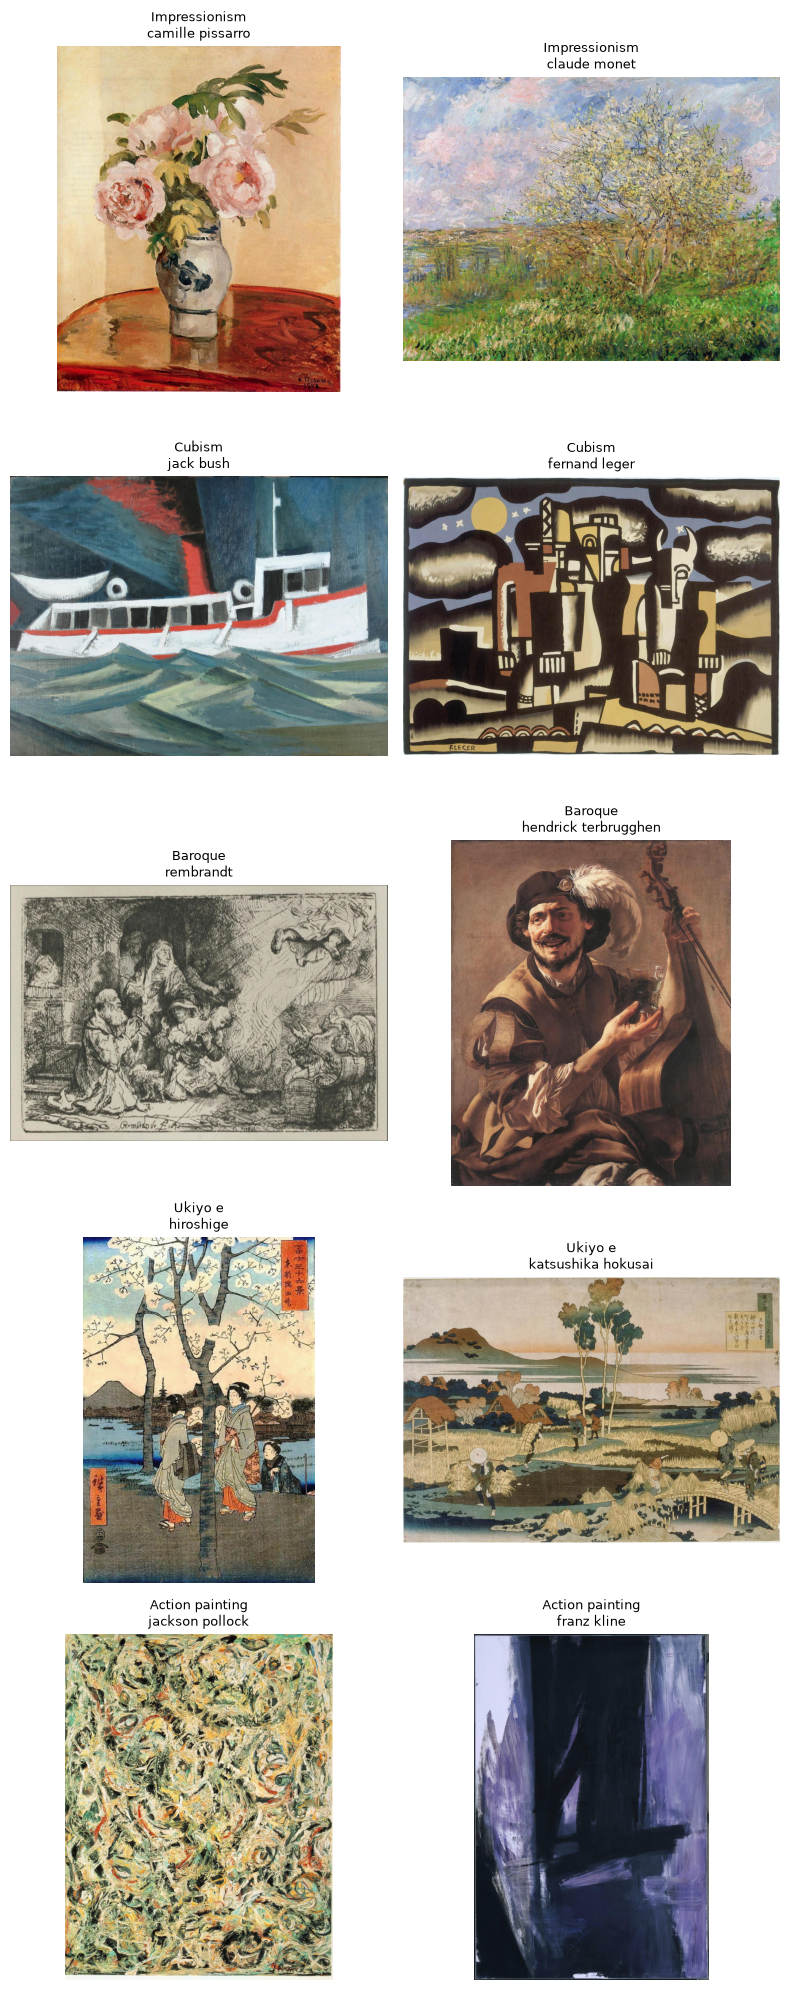

In [8]:
n_styles = len(styles)

fig, axes = plt.subplots(n_styles, N_PER_STYLE, figsize=(4 * N_PER_STYLE, 4 * n_styles))

for row, style in enumerate(styles):
    imagenes = selected[selected["style"] == style]
    for col, (_, img_row) in enumerate(imagenes.iterrows()):
        ax = axes[row, col]

        path = kagglehub.dataset_download(
            DATASET,
            path=img_row["filename"]
        )

        img = Image.open(path)

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f'{style}\n{img_row["artist"]}', fontsize=9)

plt.tight_layout()
plt.show()

## Preparación de las imágenes (actividades b y c)

Antes de agrupar colores hay que transformar cada imagen a una representación adecuada para el clustering. El pipeline tiene cuatro pasos, cada uno con su justificación:

**1. Carga y orden de canales (BGR -> RGB).** `OpenCV` lee las imágenes en orden BGR. Se convierten a RGB para que las visualizaciones (`matplotlib`) muestren los colores reales y para partir de una convención estándar antes de pasar a Lab.

**2. Redimensionado: lado mayor a `max_dim=150` px, interpolación por área.** Una obra de WikiArt puede tener millones de píxeles, pero el clustering de color no necesita resolución espacial: solo la *distribución* de colores, que se conserva al submuestrear la imagen. Reducir a 150 px baja el número de muestras de ~10^6 a ~10^4 y hace que la búsqueda de `k` por imagen (actividad d, varias corridas de K-Means por imagen) sea viable en tiempo. Se usa `cv2.INTER_AREA`, que promedia los píxeles de cada región al reducir: no inventa colores nuevos (a diferencia de interpolaciones bicúbicas), así que la paleta resultante no se contamina. Solo se reduce (nunca se amplía): si la imagen ya es menor a 150 px se deja igual.

**3. Conversión a espacio de color CIELAB.** K-Means y MeanShift agrupan minimizando distancia euclidiana. En RGB la distancia euclidiana no se corresponde con la diferencia de color que percibe el ojo (dos pares de colores a la misma distancia RGB pueden verse muy distintos o casi iguales). CIELAB está diseñado para ser aproximadamente *perceptualmente uniforme*: distancia euclidiana en Lab ~ diferencia percibida. Agrupar en Lab produce clusters que se corresponden con "colores que una persona agruparía". `L` es luminosidad, `a` el eje verde-rojo y `b` el azul-amarillo. (En Lab de 8 bits de OpenCV los tres canales quedan en el rango 0–255, con 128 como neutro en `a` y `b`.)

**4. Aplanado a matriz `(n_píxeles, 3)`.** Cada píxel se trata como una muestra independiente de 3 dimensiones `(L, a, b)`. Se descarta la posición `(x, y)`: el objetivo es agrupar colores, no regiones de la imagen.

**Decisión: no se estandariza ni normaliza.** Los tres canales de Lab ya comparten rango (0–255) y tienen significado perceptual homogéneo, así que ninguno domina artificialmente la distancia. Aplicar z-score por canal deformaría precisamente las distancias perceptuales que motivaron elegir Lab, y escalar a [0,1] no aportaría nada porque el rango ya es común. Por eso se pasan los píxeles Lab tal cual al modelo.

La actividad (c) consiste en dejar estos pasos encapsulados en una función reutilizable, aplicable a cualquier imagen del dataset y no solo a las 10 seleccionadas.

In [9]:
def preparar_imagen(path, max_dim=150):
    """Pipeline de preparacion de una imagen para el clustering de color.

    Pasos: carga con OpenCV -> BGR a RGB -> resize (lado mayor = max_dim,
    interpolacion por area) -> RGB a CIELAB -> aplanado a (n_pixeles, 3).

    Parametros
    ----------
    path : str o Path
        Ruta a la imagen en disco.
    max_dim : int
        Tamano al que se reduce el lado mayor. Si la imagen ya es mas
        pequena, se deja sin cambios.

    Devuelve
    --------
    img_rgb : ndarray (h, w, 3) uint8
        Imagen redimensionada en RGB, para visualizacion.
    pixeles_lab : ndarray (n_pixeles, 3) float32
        Pixeles en CIELAB, listos para pasar al modelo de clustering.
    """
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]
    escala = max_dim / max(h, w)
    if escala < 1:
        nuevo_tam = (max(1, round(w * escala)), max(1, round(h * escala)))
        img_rgb = cv2.resize(img_rgb, nuevo_tam, interpolation=cv2.INTER_AREA)

    img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype("float32")
    pixeles_lab = img_lab.reshape(-1, 3)

    return img_rgb, pixeles_lab


Aplicamos `preparar_imagen` a las 10 imágenes seleccionadas y guardamos los resultados en el diccionario `imagenes_preparadas` (indexado por `filename`), que se reutiliza en las etapas de clustering y de generación de paleta. La tabla de salida es evidencia de la reducción de píxeles que consigue el pipeline.

In [10]:
imagenes_preparadas = {}

for _, fila in selected.iterrows():
    ruta = kagglehub.dataset_download(DATASET, path=fila["filename"])
    img_rgb, pixeles_lab = preparar_imagen(ruta)
    imagenes_preparadas[fila["filename"]] = {
        "style": fila["style"],
        "artist": fila["artist"],
        "img_rgb": img_rgb,
        "pixeles_lab": pixeles_lab,
    }

# Evidencia: reduccion de pixeles por imagen (resolucion original -> resolucion tras el resize)
print(f'{"estilo":<16} {"original":>13} {"preparada":>11} {"pixeles":>9}   archivo')
for filename, datos in imagenes_preparadas.items():
    orig = cv2.imread(str(kagglehub.dataset_download(DATASET, path=filename)))
    ho, wo = orig.shape[:2]
    hp, wp = datos["img_rgb"].shape[:2]
    n_pix = datos["pixeles_lab"].shape[0]
    print(f'{datos["style"]:<16} {f"{ho}x{wo}":>13} {f"{hp}x{wp}":>11} {n_pix:>9}   {filename.split("/")[-1]}')


estilo                original   preparada   pixeles   archivo


Action painting      1782x1382     150x116     17400   jackson-pollock_eyes-in-the-heat-1946(2).jpg


Action painting      2037x1382     150x102     15300   franz-kline_torches-mauve-1960.jpg


Baroque              1382x2035     102x150     15300   rembrandt_angel-departing-from-the-family-of-tobias-1641.jpg


Baroque              1705x1382     150x122     18300   hendrick-terbrugghen_a-laughing-bravo-with-a-bass-viol-and-a-glass.jpg


...

Cubism               1382x1873     111x150     16650   fernand-leger_the-creation-of-the-world.jpg


Impressionism        1685x1382     150x123     18450   camille-pissarro_pink-peonies-1873.jpg


Impressionism        1382x1834     113x150     16950   claude-monet_springtime-1.jpg


Ukiyo e              2065x1382     150x100     15000   hiroshige_cherry-tree.jpg


Ukiyo e              1382x1961     106x150     15900   katsushika-hokusai_peasants-in-autumn.jpg


### Verificación: el redimensionado conserva la distribución de color

El paso más agresivo del pipeline es la reducción a 150 px. Para justificar que no distorsiona la paleta, comparamos una imagen antes y después del resize en dos planos:

- **Visual**: original vs. redimensionada lado a lado; la composición de colores se ve igual.
- **Cuantitativo**: color RGB promedio y desviación estándar por canal. Se espera que **la media por canal se conserve** (misma tendencia central de cada color) y que la **desviación estándar baje algo**: `cv2.INTER_AREA` promedia píxeles vecinos, así que atenúa la textura fina y el "ruido" de pincelada. Para el clustering de color esto no es un problema —incluso ayuda—: los colores dominantes (los centros de los clusters) dependen de dónde se concentra la masa de píxeles, no de la varianza local, así que no se desplazan.

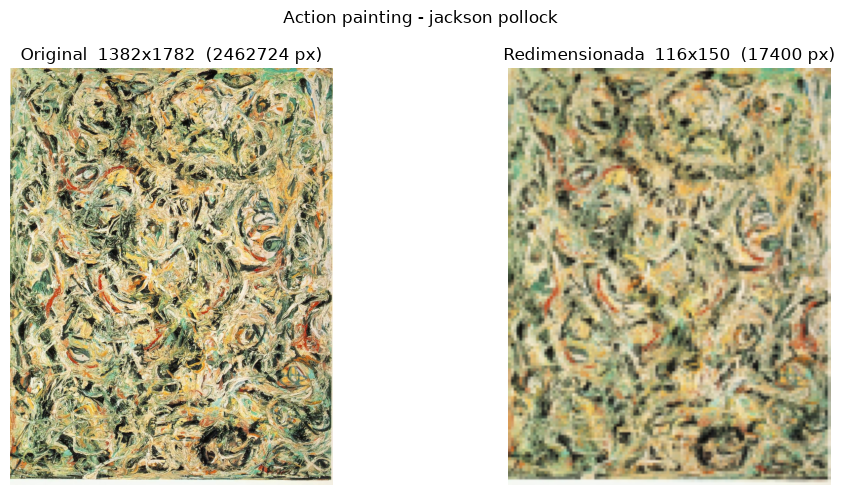

                            R                  G                  B   (media +/- desv. est.)
original    168.0 +/-  66.2  159.7 +/-  61.5  119.5 +/-  56.8
reducida    168.0 +/-  48.8  159.7 +/-  43.2  119.5 +/-  38.1


In [11]:
ejemplo = selected.iloc[0]
ruta_ejemplo = kagglehub.dataset_download(DATASET, path=ejemplo["filename"])

orig_rgb = cv2.cvtColor(cv2.imread(str(ruta_ejemplo), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
red_rgb = imagenes_preparadas[ejemplo["filename"]]["img_rgb"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(orig_rgb)
axes[0].set_title(f'Original  {orig_rgb.shape[1]}x{orig_rgb.shape[0]}  ({orig_rgb.shape[0] * orig_rgb.shape[1]} px)')
axes[0].axis("off")
axes[1].imshow(red_rgb)
axes[1].set_title(f'Redimensionada  {red_rgb.shape[1]}x{red_rgb.shape[0]}  ({red_rgb.shape[0] * red_rgb.shape[1]} px)')
axes[1].axis("off")
fig.suptitle(f'{ejemplo["style"]} - {ejemplo["artist"]}')
plt.tight_layout()
plt.show()

orig_flat = orig_rgb.reshape(-1, 3)
red_flat = red_rgb.reshape(-1, 3)
print(f'{"":<10} {"R":>18} {"G":>18} {"B":>18}   (media +/- desv. est.)')
for etiqueta, datos in [("original", orig_flat), ("reducida", red_flat)]:
    m = datos.mean(axis=0)
    s = datos.std(axis=0)
    print(f'{etiqueta:<10} ' + ' '.join(f'{m[c]:6.1f} +/- {s[c]:5.1f}' for c in range(3)))


Con el pipeline de preparación definido y encapsulado en `preparar_imagen` (actividades b y c completas), y los píxeles Lab de las 10 imágenes disponibles en `imagenes_preparadas`, el siguiente paso es la actividad (d): el modelo de agrupación por imagen, con búsqueda del número de clusters `k` de forma individual para cada una (no un `k` fijo) y una métrica que justifique la elección.

## Modelo de agrupación por imagen (actividad d)

El objetivo es encontrar, **para cada imagen por separado**, cuántos colores dominantes la describen y cuáles son. El número de clusters `k` no se fija de forma global: se busca de manera individual para cada obra, porque un bodegón barroco monocromo y un Pollock no tienen la misma riqueza cromática.

Se ajusta **K-Means** (`k-means++`, `n_init=10`, `random_state` fijo) sobre los píxeles Lab para cada `k` en el rango **2 a 12** y, de ese barrido, se elige un `k` por imagen. K-Means es el método principal porque es rápido (~110 ajustes en total), determinista y su único hiperparámetro relevante es `k`, lo que convierte la elección de `k` en una búsqueda de hiperparámetro limpia.

### Métrica de decisión: método del codo (primaria), silhouette y MeanShift (verificación)

Se calculan tres señales por imagen:

1. **Codo de la inercia (criterio de decisión).** Se grafica la inercia (suma de distancias al cuadrado intra-cluster) frente a `k` y se toma el `k` del "codo": el punto de rendimientos decrecientes, donde añadir un cluster más ya casi no reduce la distorsión. Se localiza de forma objetiva con el método de Kneedle: se normalizan ambos ejes a `[0, 1]`, se traza la recta que une el primer y el último punto de la curva, y el codo es el `k` con **máxima distancia vertical a esa recta**. Es el criterio adecuado para extraer una paleta: busca el `k` más chico que ya captura la variación de color de la imagen.

2. **Silhouette (verificación, no decide).** Mide cohesión frente a separación, acotado en `[-1, 1]`. Se probó como criterio primario pero **colapsa a `k = 2` en casi todas las imágenes**: el silhouette premia pocos clusters muy separados (típicamente el eje claro/oscuro de la obra), no la granularidad cromática que necesita una paleta. Se reporta como control: sirve para ver que la partición del codo tiene estructura razonable (silhouette claramente positivo), no para fijar `k`. Se evalúa sobre una submuestra de 2000 píxeles porque es O(n^2).

3. **MeanShift (contraste independiente).** No recibe `k`: lo deduce de la densidad local. El `bandwidth` se estima por imagen con `estimate_bandwidth` (mismo `quantile`). Corre sobre una submuestra de 3000 píxeles (O(n^2) por iteración; aquí solo interesa *cuántos* clusters encuentra). Si su número de clusters acompaña al `k` del codo, refuerza que ese `k` no es un artefacto de K-Means.

In [12]:
K_MIN, K_MAX = 2, 12
SAMPLE_SILHOUETTE = 2000   # pixeles para evaluar silhouette (metrica O(n^2))
SAMPLE_MEANSHIFT = 3000    # pixeles para MeanShift (O(n^2) por iteracion)
RANDOM_STATE = 42


def barrido_k_kmeans(pixeles_lab, k_min=K_MIN, k_max=K_MAX,
                     sample_silhouette=SAMPLE_SILHOUETTE, random_state=RANDOM_STATE):
    """Ajusta K-Means para cada k en [k_min, k_max] sobre los pixeles Lab.

    Para cada k devuelve la inercia (para el metodo del codo) y el
    silhouette score (calculado sobre una submuestra aleatoria de pixeles
    porque es O(n^2)).

    Devuelve un DataFrame con columnas: k, inercia, silhouette.
    """
    n = len(pixeles_lab)
    filas = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(pixeles_lab)
        sil = silhouette_score(
            pixeles_lab, labels,
            sample_size=min(sample_silhouette, n), random_state=random_state,
        )
        filas.append({"k": k, "inercia": km.inertia_, "silhouette": sil})
    return pd.DataFrame(filas)


def elegir_k_codo(ks, inercias):
    """Metodo del codo (Kneedle): k con la maxima distancia vertical a la
    recta que une el primer y el ultimo punto de la curva de inercia, con
    ambos ejes normalizados a [0, 1]. Es el punto de rendimientos
    decrecientes de agregar mas clusters.
    """
    ks = np.asarray(ks, dtype=float)
    inercias = np.asarray(inercias, dtype=float)
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (inercias - inercias.min()) / (inercias.max() - inercias.min())
    recta = y[0] + (y[-1] - y[0]) * x     # curva convexa decreciente -> queda por debajo
    return int(ks[np.argmax(recta - y)])


def contraste_meanshift(pixeles_lab, quantile=0.2,
                        sample_meanshift=SAMPLE_MEANSHIFT, random_state=RANDOM_STATE):
    """Corre MeanShift sobre una submuestra de pixeles como contraste del
    numero de clusters. MeanShift deduce cuantos clusters hay a partir de
    la densidad; el bandwidth se estima con estimate_bandwidth.

    Devuelve (n_clusters, bandwidth).
    """
    n = len(pixeles_lab)
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n, size=min(sample_meanshift, n), replace=False)
    muestra = pixeles_lab[idx]

    bw = estimate_bandwidth(
        muestra, quantile=quantile,
        n_samples=min(500, len(muestra)), random_state=random_state,
    )
    if bw <= 0:
        return 1, float(bw)

    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(muestra)
    return int(len(np.unique(ms.labels_))), float(bw)


Corremos el barrido de `k` y el contraste con MeanShift sobre las 10 imágenes. Para cada una se guarda en `resultados_clustering`:

- `curva_k`: la tabla de `inercia` y `silhouette` por `k` (para las gráficas del codo y del silhouette).
- `best_k`: el `k` del **codo** (criterio de decisión). `k_silhouette`: el `k` que maximiza el silhouette (solo control).
- `centros_lab` y `labels`: el modelo K-Means final reajustado con `best_k` sobre todos los píxeles (los centros son los colores dominantes; se usan en la actividad f para armar la paleta).
- `proporciones`: fracción de píxeles asignada a cada cluster (peso de cada color en la imagen).
- `ms_n_clusters` y `ms_bandwidth`: el resultado de MeanShift.

In [13]:
resultados_clustering = {}

for filename, datos in imagenes_preparadas.items():
    pixeles = datos["pixeles_lab"]

    curva = barrido_k_kmeans(pixeles)
    best_k = elegir_k_codo(curva["k"], curva["inercia"])
    k_sil = int(curva.loc[curva["silhouette"].idxmax(), "k"])

    km = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(pixeles)
    proporciones = np.bincount(labels, minlength=best_k) / len(labels)

    ms_k, ms_bw = contraste_meanshift(pixeles)

    resultados_clustering[filename] = {
        "style": datos["style"],
        "artist": datos["artist"],
        "curva_k": curva,
        "best_k": best_k,
        "k_silhouette": k_sil,
        "sil_en_best_k": float(curva.loc[curva["k"] == best_k, "silhouette"].iloc[0]),
        "centros_lab": km.cluster_centers_,
        "labels": labels,
        "proporciones": proporciones,
        "ms_n_clusters": ms_k,
        "ms_bandwidth": ms_bw,
    }

print(f'{"estilo":<16} {"k (codo)":>9} {"k (silh.)":>10} {"silh.@codo":>11} {"MeanShift":>10} {"bandwidth":>10}   archivo')
for filename, r in resultados_clustering.items():
    print(f'{r["style"]:<16} {r["best_k"]:>9} {r["k_silhouette"]:>10} {r["sil_en_best_k"]:>11.3f} '
          f'{r["ms_n_clusters"]:>10} {r["ms_bandwidth"]:>10.2f}   {filename.split("/")[-1]}')

ks = [r["best_k"] for r in resultados_clustering.values()]
print(f'\nRango de k (codo) elegido por imagen: {min(ks)} a {max(ks)}  (no hay un k fijo unico para todas)')


estilo            k (codo)  k (silh.)  silh.@codo  MeanShift  bandwidth   archivo
Action painting          5          2       0.382          1      24.47   jackson-pollock_eyes-in-the-heat-1946(2).jpg
Action painting          5          3       0.569          3      21.21   franz-kline_torches-mauve-1960.jpg
Baroque                  4          2       0.577          6      15.75   rembrandt_angel-departing-from-the-family-of-tobias-1641.jpg
Baroque                  5          2       0.502          4      15.90   hendrick-terbrugghen_a-laughing-bravo-with-a-bass-viol-and-a-glass.jpg
Cubism                   5          2       0.526          3      29.99   jack-bush_ferry-at-bigwin-island-1952.jpg
Cubism                   4          2       0.565          3      24.05   fernand-leger_the-creation-of-the-world.jpg
Impressionism            5          2       0.433          2      26.94   camille-pissarro_pink-peonies-1873.jpg
Impressionism            4          2       0.409          2   

Para cada imagen graficamos las dos curvas del barrido: la **inercia** (rojo, eje derecho) con una línea vertical llena en el `k` del **codo** (criterio de decisión), y el **silhouette** (azul, eje izquierdo) con una línea punteada en su máximo (control). En el título se anota `k (codo)`, `k (silhouette)` y el número de clusters de MeanShift.

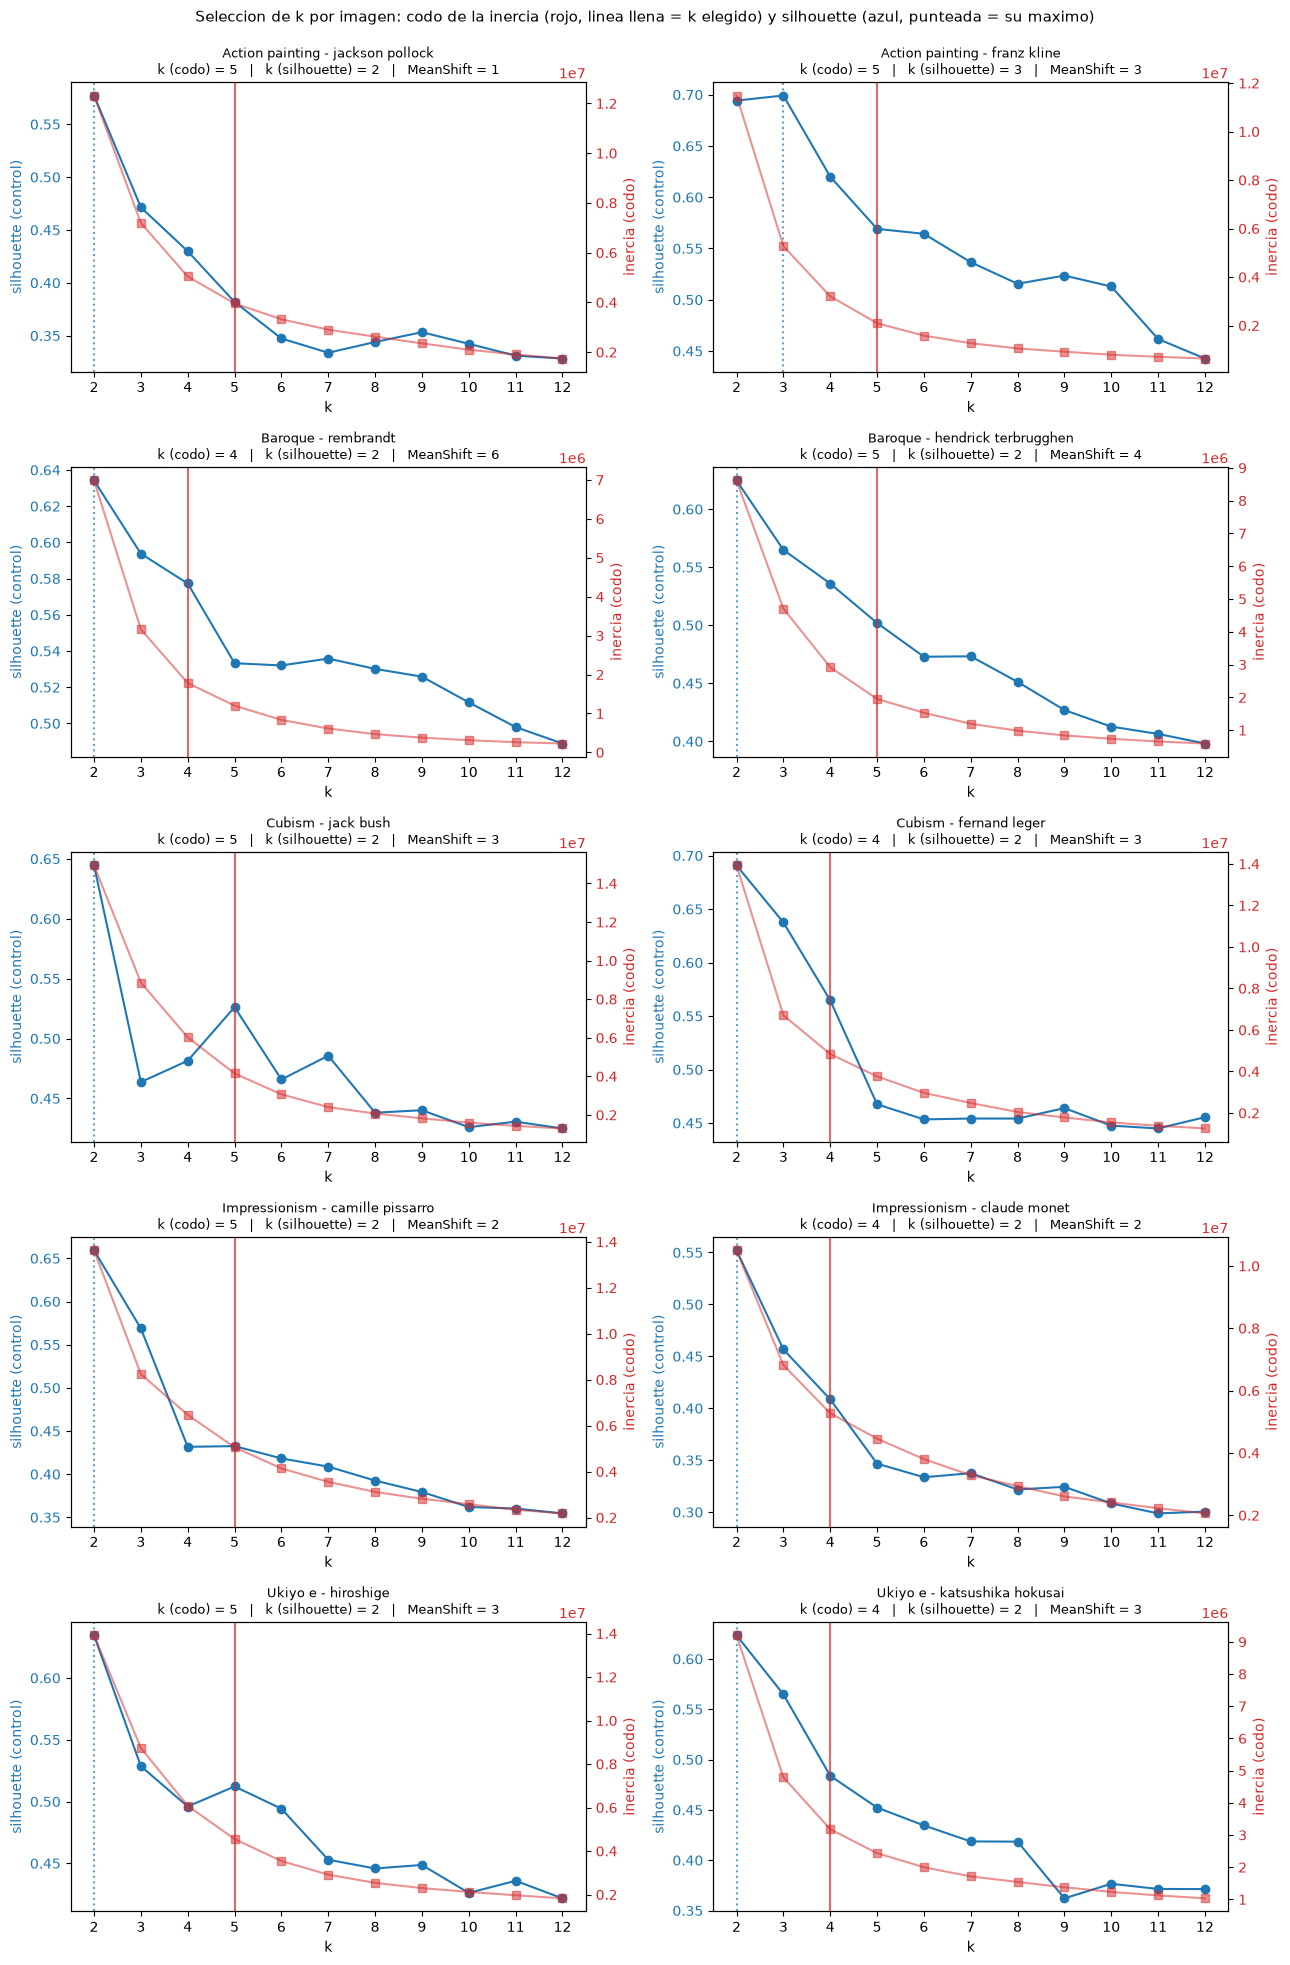

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(13, 20))

for ax, (filename, r) in zip(axes.ravel(), resultados_clustering.items()):
    curva = r["curva_k"]

    ax.plot(curva["k"], curva["silhouette"], "o-", color="tab:blue")
    ax.axvline(r["k_silhouette"], color="tab:blue", ls=":", alpha=0.7)
    ax.set_xlabel("k")
    ax.set_ylabel("silhouette (control)", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax.set_xticks(curva["k"])

    ax2 = ax.twinx()
    ax2.plot(curva["k"], curva["inercia"], "s-", color="tab:red", alpha=0.5)
    ax2.axvline(r["best_k"], color="tab:red", ls="-", alpha=0.7)
    ax2.set_ylabel("inercia (codo)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax.set_title(f'{r["style"]} - {r["artist"]}\nk (codo) = {r["best_k"]}   |   k (silhouette) = {r["k_silhouette"]}   |   MeanShift = {r["ms_n_clusters"]}',
                 fontsize=9)

fig.suptitle("Seleccion de k por imagen: codo de la inercia (rojo, linea llena = k elegido) y silhouette (azul, punteada = su maximo)",
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


### Lectura de resultados

- **`k` se recalcula por imagen.** El criterio del codo da `k = 4` o `k = 5` según la obra (Baroque de Rembrandt y los dos Cubism y dos Impressionism "pares" caen en 4; el resto en 5). No es un `k` fijo aplicado a todas: el mismo procedimiento, corrido sobre una imagen de complejidad cromática distinta (p. ej. un dibujo casi monocromo), elegiría un `k` menor. El rango es estrecho porque, a 150 px, estas diez obras tienen una complejidad de color efectiva parecida y la curva de inercia baja de forma suave, sin un quiebre abrupto.

- **El silhouette confirma que la partición tiene estructura, pero no sirve para fijar `k`.** En `k` del codo el silhouette va de 0.38 a 0.58 (claramente positivo: los clusters están separados). Su máximo, en cambio, está casi siempre en `k = 2`: como se explicó, premia particiones gruesas (claro/oscuro) y no la granularidad que necesita una paleta. Por eso es control y no criterio.

- **MeanShift acompaña de forma razonable.** Sin recibir `k`, encuentra entre 2 y 6 clusters en 9 de 10 imágenes, en el mismo orden de magnitud que el codo. La excepción es el Pollock "Eyes in the Heat", donde el `bandwidth` estimado (24.5) resulta grande y colapsa todo en 1 cluster; es una limitación conocida de MeanShift (muy sensible al `bandwidth`) y la razón por la que se usa solo como contraste y no como método principal.

Con `resultados_clustering` poblado (centros Lab = colores dominantes, y `proporciones` = peso de cada color), el siguiente paso es la actividad (e), la visualización 2D de la distribución de colores, y la (f), la función que arma el muestrario de la paleta.

## Visualización 2D de la distribución de colores (actividad e)

Cada imagen preparada es una nube de píxeles en CIELAB (3D). Para *ver* cómo se distribuyen esos colores y cómo los agrupa K-Means, proyectamos la nube a 2D.

**Por qué t-SNE (y no PCA).** t-SNE preserva la estructura *local*: píxeles de color parecido quedan cerca en el plano y los grupos densos se separan visualmente, que es justo lo que queremos mostrar (la segmentación en tonos). PCA daría una proyección lineal sobre las dos direcciones de mayor varianza, más fiel a las distancias globales pero con tendencia a solapar grupos que en Lab sí están separados. Se elige t-SNE por ser una visualización exploratoria, no una medida. *Advertencia de lectura:* en un mapa t-SNE las distancias absolutas y los tamaños de los grupos no son cuantitativos; solo es fiable la vecindad (qué está cerca de qué).

**Submuestreo.** t-SNE es O(n^2); los ~22.500 píxeles por imagen son demasiados. Se toman `SAMPLE_TSNE = 3000` píxeles al azar por imagen (`random_state=42`), suficientes para ver la forma de la distribución.

**`perplexity = 30`** (valor por defecto de scikit-learn): razonable para unos miles de puntos; equilibra vecindario cercano y estructura global. `init="pca"` para una inicialización estable y reproducible.

**Cómo se colorea.** Cada punto se pinta con **su color RGB real** (el del píxel), así el gráfico es literalmente la nube de colores de la obra. Se prefiere esto a colorear por id de clúster con una paleta categórica arbitraria: como K-Means agrupa *en el espacio de color*, cada clúster ya es una región de color coherente, y pintar por color real muestra a la vez la distribución y la partición. La asignación a clústeres se hace explícita superponiendo los **centros de K-Means** (marcador `X`, tamaño proporcional al peso del color en la imagen). Para situar los centros en el mismo plano que los píxeles (t-SNE no tiene `transform`) se corre t-SNE una sola vez sobre la pila `[muestra de píxeles ; centros]` y luego se separan.

Se reutilizan `best_k`, `labels` y `centros_lab` ya calculados en la actividad (d).

In [15]:
SAMPLE_TSNE = 3000   # pixeles por imagen para t-SNE (O(n^2))
PERPLEXITY = 30      # valor por defecto de sklearn; adecuado para unos miles de puntos


def lab_a_rgb(pixeles_lab):
    """Convierte pixeles CIELAB (rango 8 bits de OpenCV, canales 0-255) de vuelta
    a RGB en [0, 1], para poder pintar cada punto con su color real.
    """
    lab = pixeles_lab.reshape(-1, 1, 3).astype("uint8")
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB).reshape(-1, 3)
    return rgb / 255.0


def proyeccion_2d_colores(pixeles_lab, centros_lab, sample=SAMPLE_TSNE,
                          perplexity=PERPLEXITY, random_state=RANDOM_STATE):
    """Proyecta a 2D con t-SNE la nube de colores (Lab) de una imagen.

    Para situar los centros de los clusters en el mismo plano que los pixeles
    (t-SNE no tiene metodo transform), se corre t-SNE una sola vez sobre la pila
    [muestra de pixeles ; centros] y luego se separan las dos partes.

    Devuelve
    --------
    xy_pix : ndarray (m, 2)   coordenadas 2D de la muestra de pixeles
    xy_cen : ndarray (k, 2)   coordenadas 2D de los centros de cluster
    idx    : ndarray (m,)     indices de los pixeles muestreados, para recuperar
                              sus labels y su color RGB
    """
    n = len(pixeles_lab)
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n, size=min(sample, n), replace=False)
    muestra = pixeles_lab[idx]

    pila = np.vstack([muestra, centros_lab]).astype("float32")
    perp = min(perplexity, (len(pila) - 1) / 3)   # cota de sklearn: perplexity < n / 3
    emb = TSNE(n_components=2, perplexity=perp, init="pca",
               random_state=random_state).fit_transform(pila)

    k = len(centros_lab)
    return emb[:-k], emb[-k:], idx

Aplicamos la proyección a las 10 imágenes y las mostramos en una grilla 5x2. Cada punto es un píxel con su color real; las `X` son los centros de K-Means (tamaño proporcional a la proporción del color en la imagen) rotulados con su índice de clúster. Guardamos las proyecciones en `proyecciones_2d` para reutilizarlas en la muestra final (actividad g).

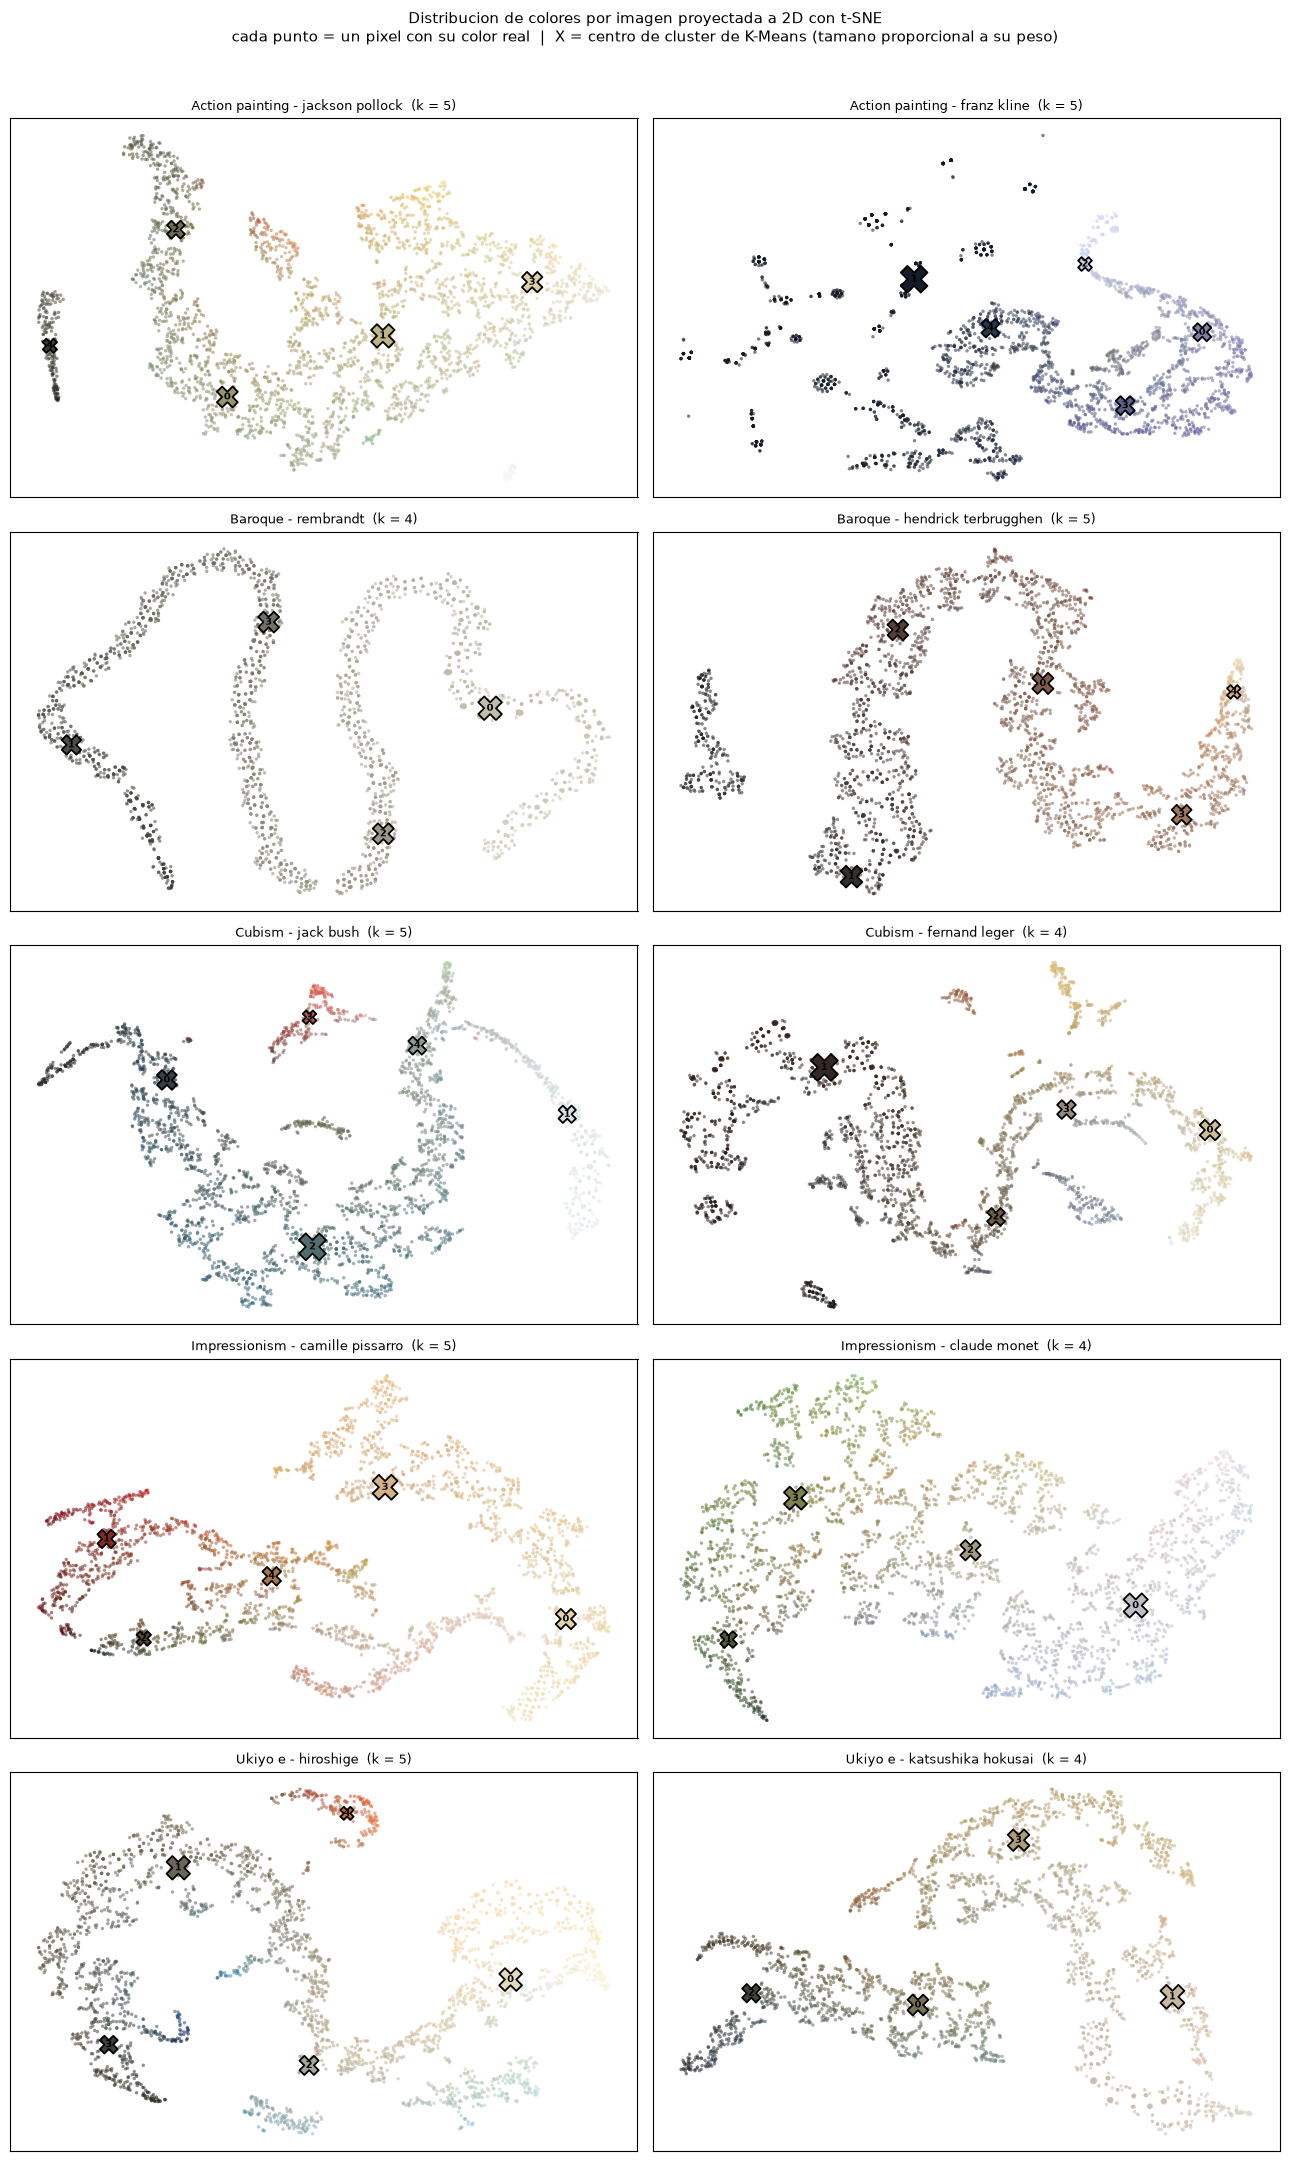

In [16]:
proyecciones_2d = {}

fig, axes = plt.subplots(5, 2, figsize=(13, 22))

for ax, (filename, r) in zip(axes.ravel(), resultados_clustering.items()):
    pixeles = imagenes_preparadas[filename]["pixeles_lab"]
    xy_pix, xy_cen, idx = proyeccion_2d_colores(pixeles, r["centros_lab"])

    proyecciones_2d[filename] = {
        "xy_pix": xy_pix,
        "xy_cen": xy_cen,
        "idx": idx,
        "labels": r["labels"][idx],
    }

    ax.scatter(xy_pix[:, 0], xy_pix[:, 1], c=lab_a_rgb(pixeles[idx]),
               s=6, alpha=0.55, linewidths=0)

    ax.scatter(xy_cen[:, 0], xy_cen[:, 1], c=lab_a_rgb(r["centros_lab"]),
               s=60 + 700 * r["proporciones"], marker="X",
               edgecolors="black", linewidths=1.3, zorder=3)
    for j, (cx, cy) in enumerate(xy_cen):
        ax.annotate(str(j), (cx, cy), fontsize=7, weight="bold",
                    ha="center", va="center", zorder=4)

    ax.set_title(f'{r["style"]} - {r["artist"]}  (k = {r["best_k"]})', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Distribucion de colores por imagen proyectada a 2D con t-SNE\n"
    "cada punto = un pixel con su color real  |  X = centro de cluster de K-Means (tamano proporcional a su peso)",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Lectura de la visualización 2D

- **La nube de color se separa en regiones coherentes.** En casi todas las obras t-SNE forma varios grupos densos y cada centro de K-Means (`X`) cae dentro de uno, lo que confirma que la partición de la actividad (d) sigue la estructura real de los datos y no corta grupos por la mitad.

- **El tamaño de las `X` refleja la paleta.** Los centros grandes (colores dominantes) se sitúan sobre las manchas de puntos más pobladas; los pequeños, sobre grupos periféricos de tonos de acento. Esto es lo que la actividad (f) convertirá en un muestrario ordenado por proporción.

- **Las obras más cromáticas muestran más grupos y más dispersión**; las de paleta más cerrada (Baroque) forman una nube más compacta con un gradiente claro-oscuro.

- *Recordatorio:* el mapa t-SNE es cualitativo. No deben leerse distancias absolutas ni densidades entre grupos; sí es válido leer qué colores quedan juntos y cómo se reparten los centros.

Con `proyecciones_2d` y `resultados_clustering` disponibles, el siguiente paso es la actividad (f): la función que arma el muestrario de la paleta a partir de los centros y sus proporciones.

## Función de generación de la paleta (actividad f)

`generar_paleta(centros_lab, proporciones)` convierte el resultado del clustering de una imagen en un muestrario utilizable. Decisiones:

- **La entrada es la salida de la actividad (d).** Los centros de K-Means en Lab son, por construcción, los colores dominantes de la imagen; `proporciones` es la fracción de píxeles asignada a cada uno. No se recalcula nada.

- **Conversión a sRGB y a hexadecimal.** Los centros se pasan de Lab a RGB (misma ruta de OpenCV que en la actividad e, vía `lab_a_rgb`) y se formatean como código `#rrggbb`, que es lo que un diseñador copia y pega. La función devuelve un `DataFrame` (`rank, hex, R, G, B, proporcion`), no solo un gráfico: la paleta queda como un dato reutilizable.

- **Orden por proporción descendente.** El primer color del muestrario es el más presente en la obra; la columna `rank` hace explícito ese orden.

- **Muestrario visual proporcional.** `mostrar_paleta` dibuja las franjas de color con **ancho proporcional a su peso en la imagen** (no franjas de igual tamaño): así se ve de un vistazo qué colores dominan y cuáles son de acento. El rótulo (hex + porcentaje) se pinta en negro o blanco según la luminancia de la franja, y solo en las franjas con ancho suficiente para que el texto quepa.

In [17]:
def generar_paleta(centros_lab, proporciones):
    """Convierte los centros de cluster (colores dominantes en Lab) y sus
    proporciones en un muestrario ordenado.

    Devuelve un DataFrame con columnas rank, hex, R, G, B, proporcion,
    ordenado por proporcion descendente (el color mas presente primero).
    """
    rgb = np.rint(lab_a_rgb(np.asarray(centros_lab)) * 255).astype(int)
    orden = np.argsort(proporciones)[::-1]
    filas = []
    for rank, i in enumerate(orden, start=1):
        r, g, b = (int(v) for v in rgb[i])
        filas.append({
            "rank": rank,
            "hex": f"#{r:02x}{g:02x}{b:02x}",
            "R": r, "G": g, "B": b,
            "proporcion": round(float(proporciones[i]), 4),
        })
    return pd.DataFrame(filas)


def mostrar_paleta(paleta, ax=None, titulo=None):
    """Dibuja el muestrario de una paleta: franjas horizontales de color con
    ancho proporcional a su peso en la imagen, rotuladas con hex y porcentaje.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 1.8))

    x = 0.0
    for _, fila in paleta.iterrows():
        w = fila["proporcion"]
        color = (fila["R"] / 255, fila["G"] / 255, fila["B"] / 255)
        ax.add_patch(Rectangle((x, 0), w, 1, facecolor=color,
                               edgecolor="white", linewidth=1.5))
        luminancia = 0.2126 * color[0] + 0.7152 * color[1] + 0.0722 * color[2]
        if w > 0.05:
            ax.text(x + w / 2, 0.5, f'{fila["hex"]}\n{w * 100:.1f}%',
                    ha="center", va="center", fontsize=8,
                    color="black" if luminancia > 0.5 else "white")
        x += w

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    if titulo:
        ax.set_title(titulo, fontsize=9)
    return ax

Aplicamos `generar_paleta` a las 10 imágenes seleccionadas y mostramos el muestrario de cada una en una grilla 5x2. Guardamos los `DataFrame` resultantes en `paletas` (filename -> muestrario) para reutilizarlos en la muestra final. Abajo se imprime además el `DataFrame` de una imagen para ver el formato de salida (hex + RGB + proporción).

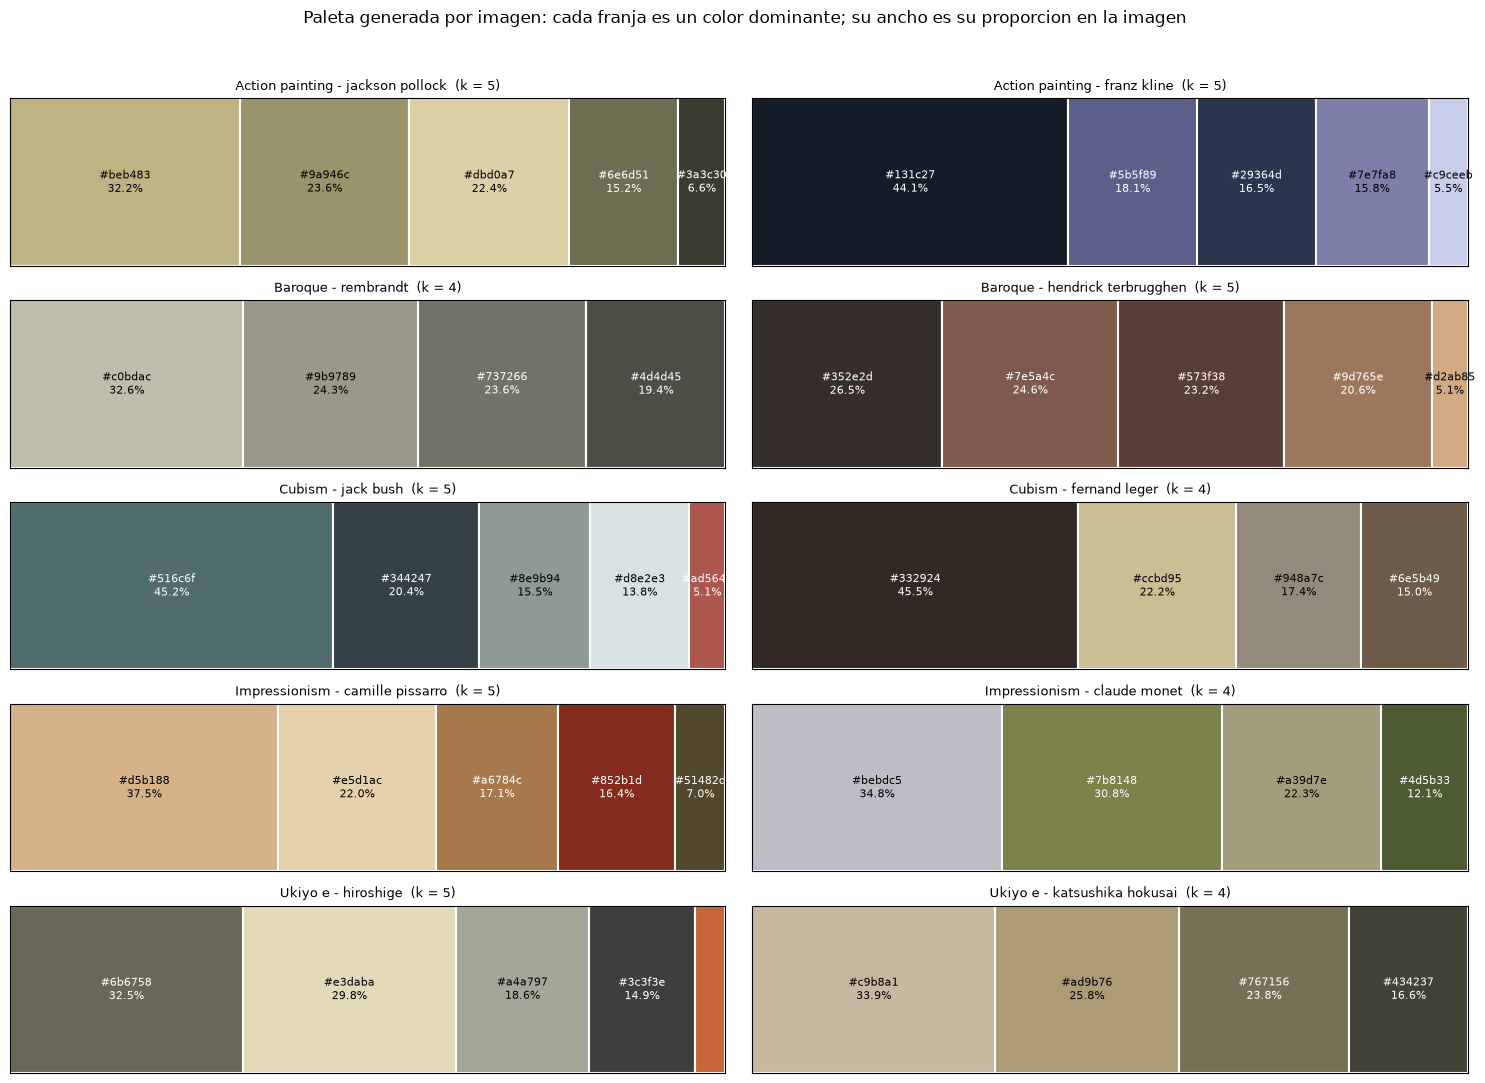

Muestrario (DataFrame) para: Action painting - jackson pollock
 rank     hex   R   G   B  proporcion
    1 #beb483 190 180 131      0.3216
    2 #9a946c 154 148 108      0.2364
    3 #dbd0a7 219 208 167      0.2238
    4 #6e6d51 110 109  81      0.1521
    5 #3a3c30  58  60  48      0.0662


In [18]:
paletas = {fn: generar_paleta(r["centros_lab"], r["proporciones"])
           for fn, r in resultados_clustering.items()}

fig, axes = plt.subplots(5, 2, figsize=(15, 11))

for ax, (fn, r) in zip(axes.ravel(), resultados_clustering.items()):
    mostrar_paleta(paletas[fn], ax=ax,
                   titulo=f'{r["style"]} - {r["artist"]}  (k = {r["best_k"]})')

fig.suptitle("Paleta generada por imagen: cada franja es un color dominante; su ancho es su proporcion en la imagen",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

ejemplo = next(iter(paletas))
r_ej = resultados_clustering[ejemplo]
print(f'Muestrario (DataFrame) para: {r_ej["style"]} - {r_ej["artist"]}')
print(paletas[ejemplo].to_string(index=False))

## Muestra final (actividad g)

Para un representante de cada uno de los 5 estilos se muestran juntos, en una fila: la **imagen preparada**, la **paleta generada** (actividad f) y la **distribución de color en 2D** (actividad e). Se toma la primera imagen de cada estilo del diccionario `resultados_clustering`, de modo que las 5 obras son de estilos cromáticamente distintos (barroco, cubismo, impresionismo, ukiyo-e, action painting) y sus paletas y nubes de color deberían verse claramente diferentes entre sí. Esto cubre el requisito de la rúbrica de mostrar el pipeline completo sobre al menos 4 imágenes de estilos distintos.

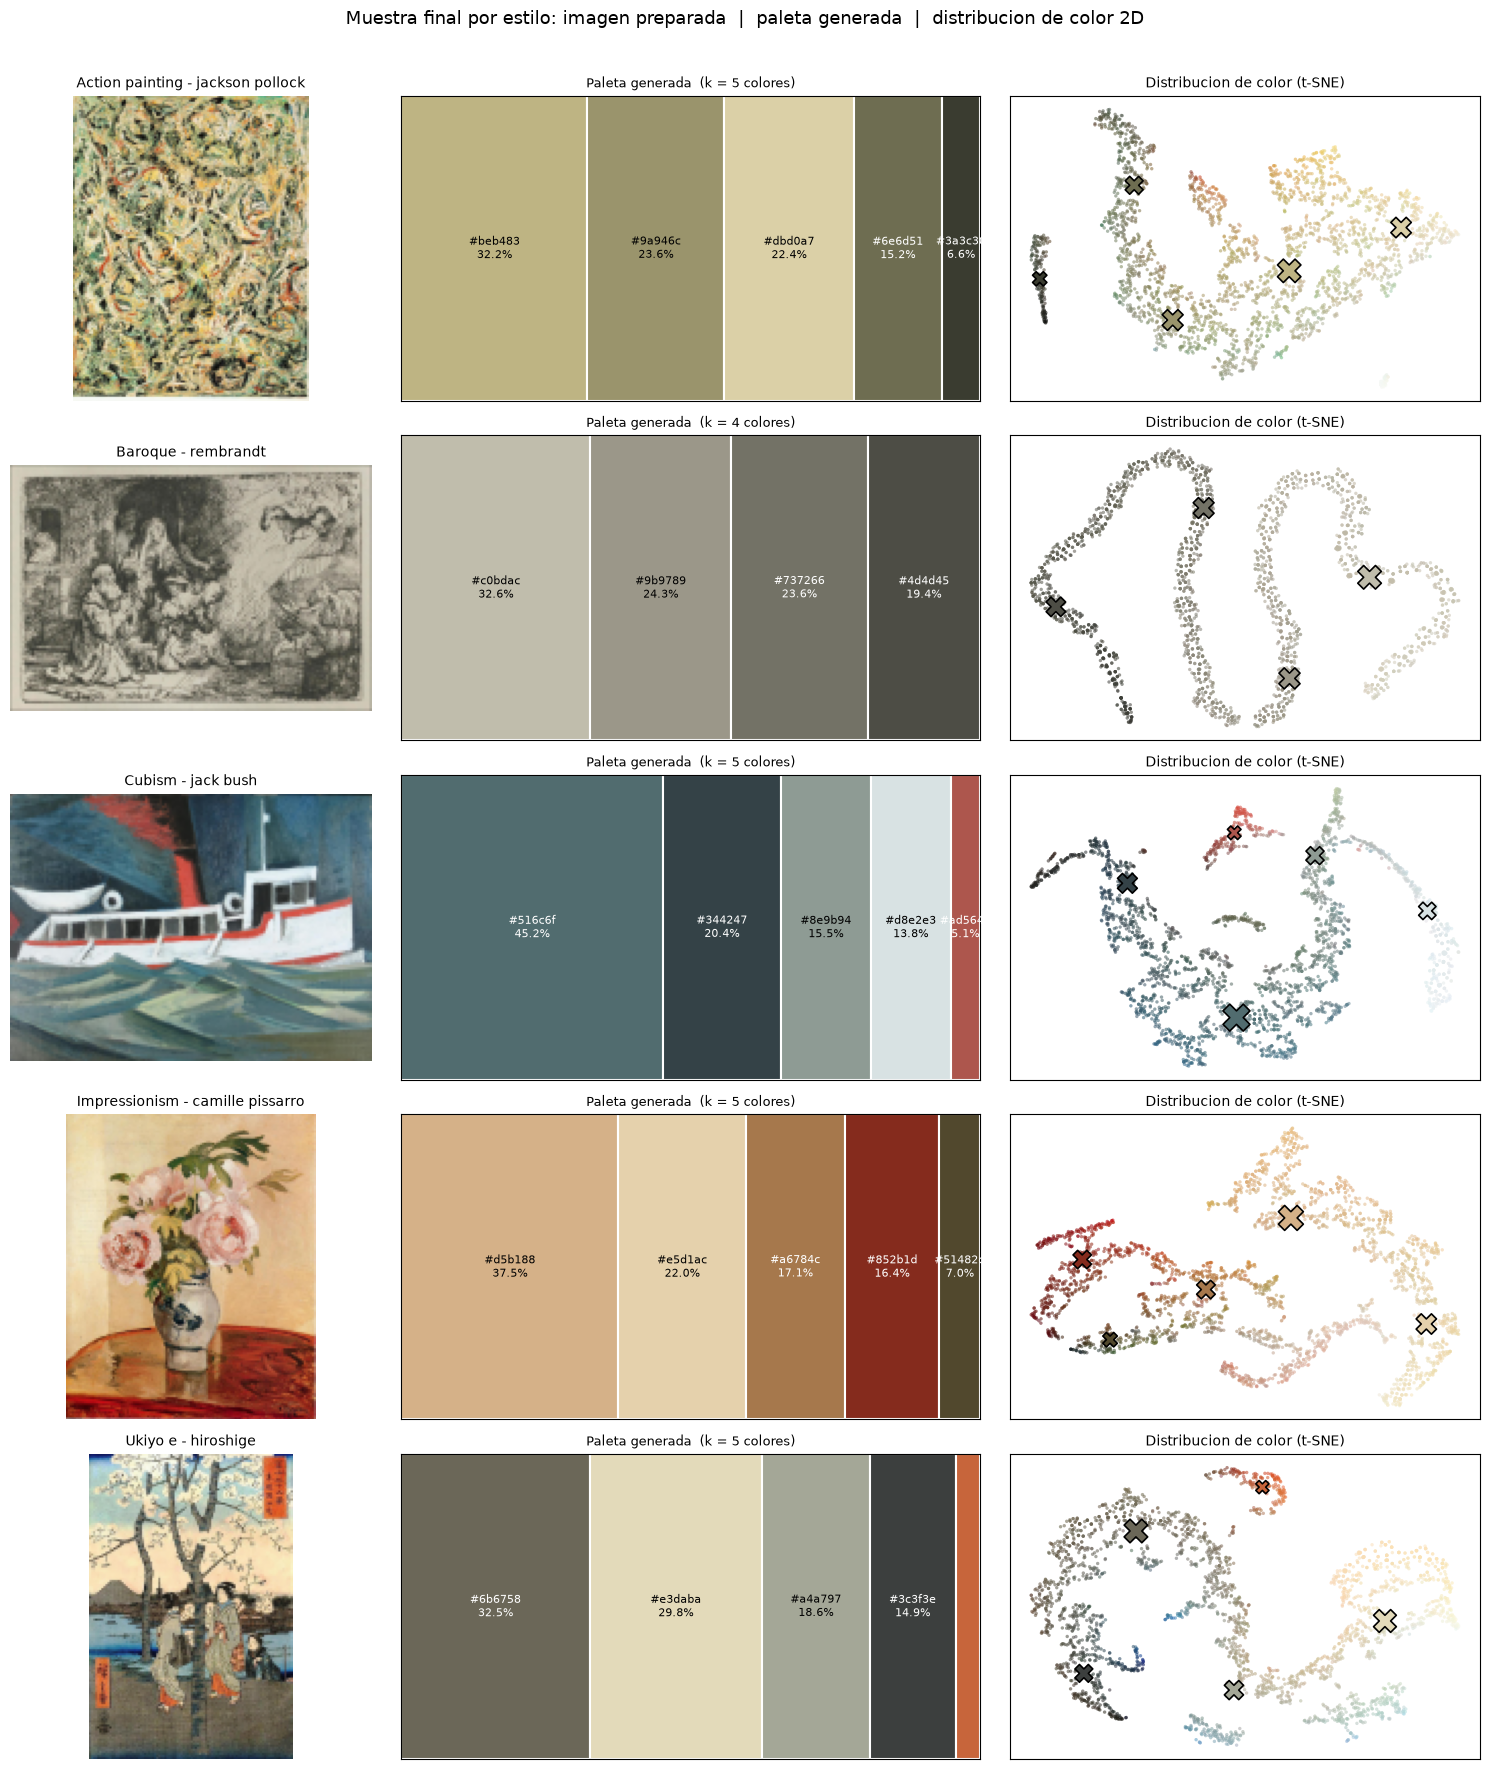

In [19]:
# un representante por estilo (el primero que aparece de cada uno)
seleccion_final = []
estilos_vistos = set()
for fn, r in resultados_clustering.items():
    if r["style"] not in estilos_vistos:
        estilos_vistos.add(r["style"])
        seleccion_final.append(fn)

n = len(seleccion_final)
fig, axes = plt.subplots(n, 3, figsize=(15, 3.6 * n),
                         gridspec_kw={"width_ratios": [1.0, 1.6, 1.3]})

for (ax_img, ax_pal, ax_2d), fn in zip(axes, seleccion_final):
    r = resultados_clustering[fn]
    datos = imagenes_preparadas[fn]

    ax_img.imshow(datos["img_rgb"])
    ax_img.set_title(f'{r["style"]} - {r["artist"]}', fontsize=10)
    ax_img.axis("off")

    mostrar_paleta(paletas[fn], ax=ax_pal,
                   titulo=f'Paleta generada  (k = {r["best_k"]} colores)')

    pr = proyecciones_2d[fn]
    pix = datos["pixeles_lab"][pr["idx"]]
    ax_2d.scatter(pr["xy_pix"][:, 0], pr["xy_pix"][:, 1], c=lab_a_rgb(pix),
                  s=6, alpha=0.55, linewidths=0)
    ax_2d.scatter(pr["xy_cen"][:, 0], pr["xy_cen"][:, 1],
                  c=lab_a_rgb(r["centros_lab"]), s=60 + 700 * r["proporciones"],
                  marker="X", edgecolors="black", linewidths=1.2, zorder=3)
    ax_2d.set_title("Distribucion de color (t-SNE)", fontsize=10)
    ax_2d.set_xticks([])
    ax_2d.set_yticks([])

fig.suptitle("Muestra final por estilo: imagen preparada  |  paleta generada  |  distribucion de color 2D",
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Lectura de la muestra final

- **Cada paleta resume la obra y se adapta a su riqueza cromática.** El grabado de Rembrandt (obra prácticamente monocroma) produce un muestrario de cuatro tonos casi neutros, una rampa de grises cálidos: el método no inventa color donde no lo hay. El Pissarro y el Jack Bush, en cambio, tienen un claro dominante y varios acentos, incluidos los rojos que el ojo busca primero (el rojo oscuro `#852b1d` del mantel en el Pissarro, 16.4%; el rojo `#ad5647` del casco del ferry en el Bush, solo 5.1% pero bien separado del resto en la nube 2D).

- **El número de colores no es fijo.** Las obras mostradas usan `k` = 4 o 5, elegido por imagen con el método del codo en la actividad (d), no un valor único aplicado a todas.

- **Las tres vistas son consistentes entre sí.** El color y el ancho de cada franja del muestrario se corresponden con la posición y el tamaño de la `X` del mismo color en la nube t-SNE de la derecha, y con lo que se ve a simple vista en la imagen preparada de la izquierda. El muestrario es, en esencia, la nube 2D de color resumida en una barra ordenada por proporción.

Con esto quedan cubiertas las actividades (a) a (g) de la rúbrica. El notebook se exporta a `reports/microproyecto1_paleta_colores.html` con `jupyter nbconvert --to html` para el entregable (ver `README.md`).